In [1]:

import pandas as pd
from weight_impact import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
summary = load_summary_intervals("summary_enriched.json")

df_intervals = intervals_to_dataframe(summary)

df_intervals.head()


,run,day,start_time,end_time,duration,leg_type,boat,name,mast,total_weight,master_leeward,avg_SOG,SOG_var,avg_TWS,avg_TWA,SOG_ref,pol_ratio,stability
0,26_11_2025_Run1,26_11_2025,1.764160e+09,1.764160e+09,97.413,upwind,1,Karl Maeder,Levi,115.49,False,21.224205,0.788214,17.435749,29.781547,22.842259,92.916403,0.944427
1,26_11_2025_Run1,26_11_2025,1.764160e+09,1.764160e+09,61.399,downwind,1,Karl Maeder,Levi,115.49,False,33.631545,0.812512,15.760737,-156.953363,31.313454,107.402858,0.934051
2,26_11_2025_Run2,26_11_2025,1.764160e+09,1.764160e+09,95.704,upwind,1,Karl Maeder,Levi,115.49,False,21.527557,0.718361,16.286399,29.539586,22.811637,94.370945,0.958964
3,26_11_2025_Run2,26_11_2025,1.764160e+09,1.764160e+09,60.496,downwind,1,Karl Maeder,Levi,115.49,False,33.153960,0.846486,16.620916,-161.793566,31.041649,106.804764,0.942170
4,26_11_2025_Run3,26_11_2025,1.764161e+09,1.764161e+09,49.395,upwind,1,Karl Maeder,Levi,120.49,False,20.857172,0.847492,17.210620,26.113069,22.809127,91.442220,0.950302


DESCRIPTIVE STATISTICS (SOG)
Leg Type  Weight (kg)  Mean (kts)  Std Dev  Nb Runs
downwind       104.99   31.395283 0.940095        2
downwind       110.49   31.931979 0.907502        7
downwind       115.49   32.332756 0.688280        9
downwind       120.49   32.323533 0.567103        3
  upwind       104.99   20.757998 0.076105        2
  upwind       110.49   21.354961 0.400574        7
  upwind       115.49   21.241513 0.594789       10
  upwind       120.49   20.624016 0.626192        4


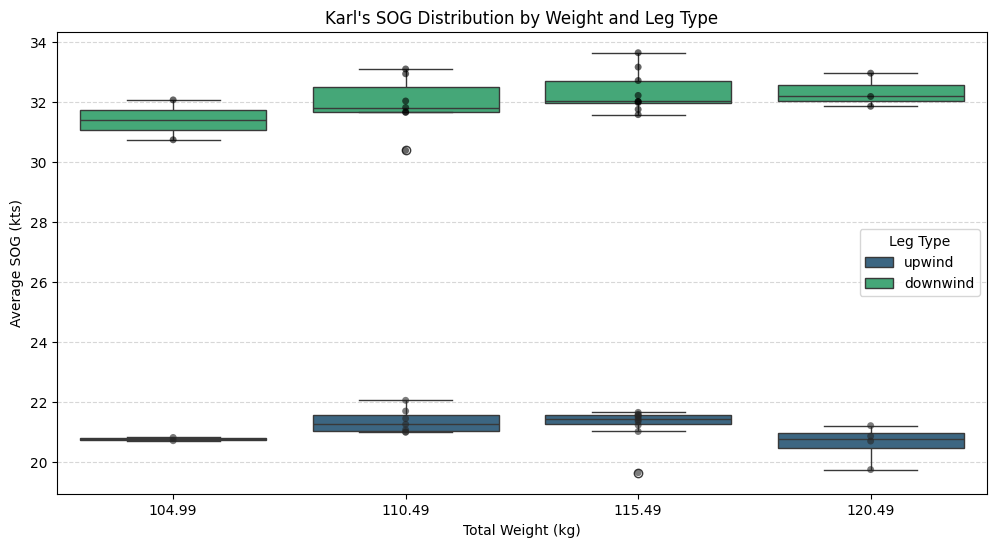

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

print("DESCRIPTIVE STATISTICS (SOG)")
stats_summary = df_intervals.groupby(['leg_type', 'total_weight'])['avg_SOG'].agg(['mean', 'std', 'count']).reset_index()
stats_summary.columns = ['Leg Type', 'Weight (kg)', 'Mean (kts)', 'Std Dev', 'Nb Runs']
print(stats_summary.to_string(index=False))

plt.figure(figsize=(12, 6))

sns.boxplot(x='total_weight', y='avg_SOG', hue='leg_type', 
            data=df_intervals, palette='viridis', dodge=False)

sns.stripplot(x='total_weight', y='avg_SOG', hue='leg_type', 
              jitter=False, data=df_intervals, dodge=False, 
              color='black', alpha=0.6, legend=False)

plt.title("Karl's SOG Distribution by Weight and Leg Type")
plt.xlabel('Total Weight (kg)')
plt.ylabel('Average SOG (kts)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Leg Type')
plt.show()

In [4]:
import scipy.stats as stats

# --- 1. GLOBAL ANOVA (Combined Days & Combined Legs) ---
print("=== GLOBAL ANOVA (Combined Days & Legs) ===")
all_weights = df_intervals['total_weight'].unique()
global_groups = [df_intervals[df_intervals['total_weight'] == w]['avg_SOG'] for w in all_weights]
total_runs_gen = len(df_intervals)

f_stat_gen, p_val_gen = stats.f_oneway(*global_groups)
status = "SIGNIFICANT" if p_val_gen < 0.05 else "NOT SIGNIFICANT"
print(f"Global ANOVA| Total Runs: {total_runs_gen:2} | F: {f_stat_gen:.4f} | p: {p_val_gen:.5f} | {status}")

print("-" * 40 + "\n")



# --- 2. GLOBAL ANOVA BY LEG TYPE (Combined Days) ---
print("=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===")
for leg in df_intervals['leg_type'].unique():
    subset_leg = df_intervals[df_intervals['leg_type'] == leg]
    weights_leg = subset_leg['total_weight'].unique()
    num_runs_leg = len(subset_leg)
    
    if len(weights_leg) > 1:
        groups_leg = [subset_leg[subset_leg['total_weight'] == w]['avg_SOG'] for w in weights_leg]
        f_l, p_l = stats.f_oneway(*groups_leg)
        status = "SIGNIFICANT" if p_l < 0.05 else "NOT SIGNIFICANT"
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | F: {f_l:.4f} | p: {p_l:.5f} | {status}")
    else:
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | Insufficient weight variations")
print("-" * 40 + "\n")


# --- 3. ANOVA BY DAY AND LEG TYPE ---
unique_days = df_intervals['day'].unique()

for day in unique_days:
    print(f"=== ANALYSIS FOR DAY: {day} ===")
    df_day = df_intervals[df_intervals['day'] == day]
    total_runs_day = len(df_day)
    
    # Global for the specific day
    weights_day = df_day['total_weight'].unique()
    if len(weights_day) > 1:
        groups_day = [df_day[df_day['total_weight'] == w]['avg_SOG'] for w in weights_day]
        f_d, p_d = stats.f_oneway(*groups_day)
        status = "SIGNIFICANT" if p_d < 0.05 else "NOT SIGNIFICANT"
        print(f"  Day Global ANOVA | Runs: {total_runs_day:2} | F: {f_d:.4f} | p: {p_d:.5f} | {status}")
    # Detail by leg type for the specific day
    for leg in df_day['leg_type'].unique():
        subset_day_leg = df_day[df_day['leg_type'] == leg]
        weights_day_leg = subset_day_leg['total_weight'].unique()
        num_runs_day_leg = len(subset_day_leg)
        
        if len(weights_day_leg) > 1:
            groups_day_leg = [subset_day_leg[subset_day_leg['total_weight'] == w]['avg_SOG'] for w in weights_day_leg]
            f_dl, p_dl = stats.f_oneway(*groups_day_leg)
            status = "SIGNIFICANT" if p_dl < 0.05 else "NOT SIGNIFICANT"
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | F: {f_dl:.4f} | p: {p_dl:.5f} | {status}")
        else:
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | Insufficient weight variations")
            
    print("-" * 40 + "\n")

=== GLOBAL ANOVA (Combined Days & Legs) ===
Global ANOVA| Total Runs: 44 | F: 0.0542 | p: 0.98313 | NOT SIGNIFICANT
----------------------------------------

=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===
Leg: UPWIND    | Total Runs: 23 | F: 2.1146 | p: 0.13213 | NOT SIGNIFICANT
Leg: DOWNWIND  | Total Runs: 21 | F: 1.0091 | p: 0.41291 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 26_11_2025 ===
  Day Global ANOVA | Runs: 26 | F: 0.0675 | p: 0.93494 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs: 14 | F: 6.7971 | p: 0.01197 | SIGNIFICANT
  Leg: DOWNWIND  | Runs: 12 | F: 1.1253 | p: 0.36628 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 27_11_2025 ===
  Day Global ANOVA | Runs: 18 | F: 0.0102 | p: 0.98989 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs:  9 | F: 0.1592 | p: 0.85628 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs:  9 | F: 1.0407 | p: 0.40927 | NOT SIGNIFICANT
----------------------------------------



In [5]:
from statsmodels.formula.api import ols

# --- 1. GLOBAL OLS REGRESSION (Combined Days) ---
print("GLOBAL OLS REGRESSION (All Days)")
for leg in df_intervals['leg_type'].unique():
    subset = df_intervals[df_intervals['leg_type'] == leg]
    num_runs = len(subset)
    
    # Model: Speed depends on Weight and Wind
    model = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset).fit()
    
    print(f"\n LEG TYPE: {leg.upper()} | Sample Size (N): {num_runs}")
    print(f"R-squared: {model.rsquared:.3f}")
    print(model.summary().tables[1])
    
    coef_weight = model.params['total_weight']
    p_weight = model.pvalues['total_weight']

    status = "SIGNIFICANT" if p_weight < 0.05 else "NOT SIGNIFICANT"
    print(f"Impact of 1kg: {coef_weight:.4f} kts | Status: {status}")
    print("-" * 60 + "\n")


# --- 2. OLS REGRESSION BY DAY ---
unique_days = df_intervals['day'].unique()

for day in unique_days:
    print(f"\n\n\n\n ANALYSIS FOR DAY: {day}")
    df_day = df_intervals[df_intervals['day'] == day]
    for leg in df_day['leg_type'].unique():
        subset_day = df_day[df_day['leg_type'] == leg]
        num_runs_day = len(subset_day)
        # We need at least 3 runs to solve for intercept + weight + TWS
        if num_runs_day > 2:
            model_day = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset_day).fit()
            
            print(f"\n LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print(f"R-squared: {model_day.rsquared:.3f}")
            print(model_day.summary().tables[1])
            
            cw = model_day.params['total_weight']
            pw = model_day.pvalues['total_weight']
            
            status = "SIGNIFICANT" if pw < 0.05 else "NOT SIGNIFICANT"
            print(f"Impact of 1kg: {cw:.4f} kts | Status: {status}")
        else:
            print(f"LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print("Not enough data points for regression on this specific day.")
            
        print("-" * 30)
    print("\n")

GLOBAL OLS REGRESSION (All Days)

 LEG TYPE: UPWIND | Sample Size (N): 23
R-squared: 0.251
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       24.2405      2.924      8.290      0.000      18.121      30.360
total_weight    -0.0032      0.029     -0.113      0.911      -0.063       0.057
avg_TWS         -0.1013      0.072     -1.402      0.177      -0.252       0.050
avg_TWA         -0.0343      0.016     -2.197      0.041      -0.067      -0.002
Impact of 1kg: -0.0032 kts | Status: NOT SIGNIFICANT
------------------------------------------------------------


 LEG TYPE: DOWNWIND | Sample Size (N): 21
R-squared: 0.200
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       27.2124      7.128      3.818      0.001      12.173      42.252
total

c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  

# Same analysis, but deleting manually runs where Karl fell

In [6]:
runs_to_remove = [
    "26_11_2025_Run3",
    "26_11_2025_Run4",
    "26_11_2025_Run5"
]

df_filtered = df_intervals.copy()
df_filtered = df_filtered[~df_filtered["run"].isin(runs_to_remove)].reset_index(drop=True)

DESCRIPTIVE STATISTICS (SOG)
Leg Type  Weight (kg)  Mean (kts)  Std Dev  Nb Runs
downwind       104.99   31.395283 0.940095        2
downwind       110.49   31.931979 0.907502        7
downwind       115.49   32.332756 0.688280        9
downwind       120.49   31.846440      NaN        1
  upwind       104.99   20.757998 0.076105        2
  upwind       110.49   21.354961 0.400574        7
  upwind       115.49   21.241513 0.594789       10
  upwind       120.49   20.692174      NaN        1


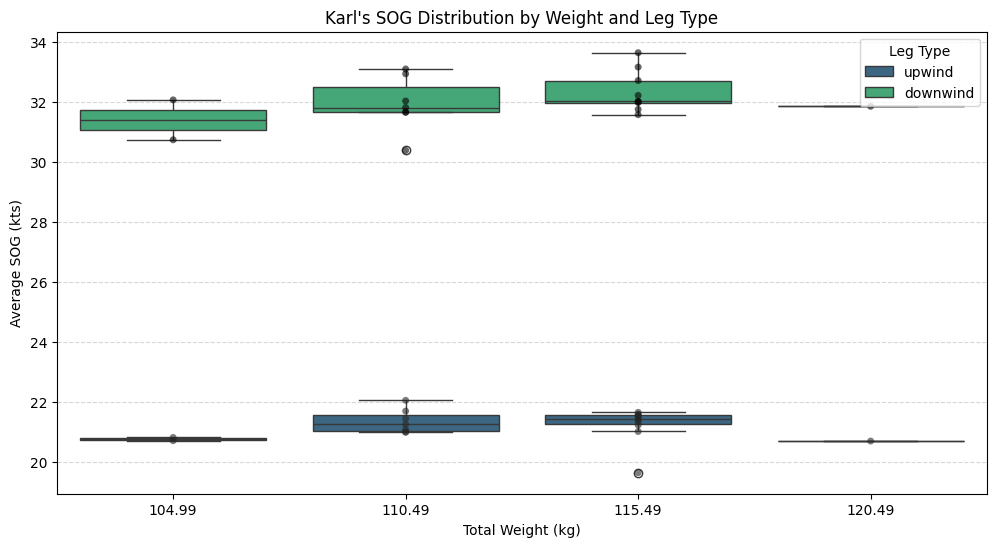

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

print("DESCRIPTIVE STATISTICS (SOG)")
stats_summary = df_filtered.groupby(['leg_type', 'total_weight'])['avg_SOG'].agg(['mean', 'std', 'count']).reset_index()
stats_summary.columns = ['Leg Type', 'Weight (kg)', 'Mean (kts)', 'Std Dev', 'Nb Runs']
print(stats_summary.to_string(index=False))

plt.figure(figsize=(12, 6))

sns.boxplot(x='total_weight', y='avg_SOG', hue='leg_type', 
            data=df_filtered, palette='viridis', dodge=False)

sns.stripplot(x='total_weight', y='avg_SOG', hue='leg_type', 
              jitter=False, data=df_filtered, dodge=False, 
              color='black', alpha=0.6, legend=False)

plt.title("Karl's SOG Distribution by Weight and Leg Type")
plt.xlabel('Total Weight (kg)')
plt.ylabel('Average SOG (kts)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Leg Type')
plt.show()

In [8]:
import scipy.stats as stats

# --- 1. GLOBAL ANOVA (Combined Days & Combined Legs) ---
print("=== GLOBAL ANOVA (Combined Days & Legs) ===")
all_weights = df_filtered['total_weight'].unique()
global_groups = [df_filtered[df_filtered['total_weight'] == w]['avg_SOG'] for w in all_weights]
total_runs_gen = len(df_filtered)

f_stat_gen, p_val_gen = stats.f_oneway(*global_groups)
status = "SIGNIFICANT" if p_val_gen < 0.05 else "NOT SIGNIFICANT"
print(f"Global ANOVA| Total Runs: {total_runs_gen:2} | F: {f_stat_gen:.4f} | p: {p_val_gen:.5f} | {status}")

print("-" * 40 + "\n")



# --- 2. GLOBAL ANOVA BY LEG TYPE (Combined Days) ---
print("=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===")
for leg in df_filtered['leg_type'].unique():
    subset_leg = df_filtered[df_filtered['leg_type'] == leg]
    weights_leg = subset_leg['total_weight'].unique()
    num_runs_leg = len(subset_leg)
    
    if len(weights_leg) > 1:
        groups_leg = [subset_leg[subset_leg['total_weight'] == w]['avg_SOG'] for w in weights_leg]
        f_l, p_l = stats.f_oneway(*groups_leg)
        status = "SIGNIFICANT" if p_l < 0.05 else "NOT SIGNIFICANT"
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | F: {f_l:.4f} | p: {p_l:.5f} | {status}")
    else:
        print(f"Leg: {leg.upper():9} | Total Runs: {num_runs_leg:2} | Insufficient weight variations")
print("-" * 40 + "\n")


# --- 3. ANOVA BY DAY AND LEG TYPE ---
unique_days = df_filtered['day'].unique()

for day in unique_days:
    print(f"=== ANALYSIS FOR DAY: {day} ===")
    df_day = df_filtered[df_filtered['day'] == day]
    total_runs_day = len(df_day)
    
    # Global for the specific day
    weights_day = df_day['total_weight'].unique()
    if len(weights_day) > 1:
        groups_day = [df_day[df_day['total_weight'] == w]['avg_SOG'] for w in weights_day]
        f_d, p_d = stats.f_oneway(*groups_day)
        status = "SIGNIFICANT" if p_d < 0.05 else "NOT SIGNIFICANT"
        print(f"  Day Global ANOVA | Runs: {total_runs_day:2} | F: {f_d:.4f} | p: {p_d:.5f} | {status}")
    # Detail by leg type for the specific day
    for leg in df_day['leg_type'].unique():
        subset_day_leg = df_day[df_day['leg_type'] == leg]
        weights_day_leg = subset_day_leg['total_weight'].unique()
        num_runs_day_leg = len(subset_day_leg)
        
        if len(weights_day_leg) > 1:
            groups_day_leg = [subset_day_leg[subset_day_leg['total_weight'] == w]['avg_SOG'] for w in weights_day_leg]
            f_dl, p_dl = stats.f_oneway(*groups_day_leg)
            status = "SIGNIFICANT" if p_dl < 0.05 else "NOT SIGNIFICANT"
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | F: {f_dl:.4f} | p: {p_dl:.5f} | {status}")
        else:
            print(f"  Leg: {leg.upper():9} | Runs: {num_runs_day_leg:2} | Insufficient weight variations")
            
    print("-" * 40 + "\n")

=== GLOBAL ANOVA (Combined Days & Legs) ===
Global ANOVA| Total Runs: 39 | F: 0.0111 | p: 0.99836 | NOT SIGNIFICANT
----------------------------------------

=== GLOBAL ANOVA BY LEG TYPE (Combined Days) ===
Leg: UPWIND    | Total Runs: 20 | F: 1.0703 | p: 0.38946 | NOT SIGNIFICANT
Leg: DOWNWIND  | Total Runs: 19 | F: 0.8911 | p: 0.46833 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 26_11_2025 ===
  Day Global ANOVA | Runs: 21 | F: 0.0036 | p: 0.99641 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs: 11 | F: 3.9453 | p: 0.06424 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs: 10 | F: 1.0281 | p: 0.40600 | NOT SIGNIFICANT
----------------------------------------

=== ANALYSIS FOR DAY: 27_11_2025 ===
  Day Global ANOVA | Runs: 18 | F: 0.0102 | p: 0.98989 | NOT SIGNIFICANT
  Leg: UPWIND    | Runs:  9 | F: 0.1592 | p: 0.85628 | NOT SIGNIFICANT
  Leg: DOWNWIND  | Runs:  9 | F: 1.0407 | p: 0.40927 | NOT SIGNIFICANT
----------------------------------------



In [9]:
from statsmodels.formula.api import ols

# --- 1. GLOBAL OLS REGRESSION (Combined Days) ---
print("GLOBAL OLS REGRESSION (All Days)")
for leg in df_filtered['leg_type'].unique():
    subset = df_filtered[df_filtered['leg_type'] == leg]
    num_runs = len(subset)
    
    # Model: Speed depends on Weight and Wind
    model = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset).fit()
    
    print(f"\n LEG TYPE: {leg.upper()} | Sample Size (N): {num_runs}")
    print(f"R-squared: {model.rsquared:.3f}")
    print(model.summary().tables[1])
    
    coef_weight = model.params['total_weight']
    p_weight = model.pvalues['total_weight']

    status = "SIGNIFICANT" if p_weight < 0.05 else "NOT SIGNIFICANT"
    print(f"Impact of 1kg: {coef_weight:.4f} kts | Status: {status}")
    print("-" * 60 + "\n")


# --- 2. OLS REGRESSION BY DAY ---
unique_days = df_filtered['day'].unique()

for day in unique_days:
    print(f"\n\n\n\n ANALYSIS FOR DAY: {day}")
    df_day = df_filtered[df_filtered['day'] == day]
    for leg in df_day['leg_type'].unique():
        subset_day = df_day[df_day['leg_type'] == leg]
        num_runs_day = len(subset_day)
        # We need at least 3 runs to solve for intercept + weight + TWS
        if num_runs_day > 2:
            model_day = ols('avg_SOG ~ total_weight + avg_TWS + avg_TWA', data=subset_day).fit()
            
            print(f"\n LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print(f"R-squared: {model_day.rsquared:.3f}")
            print(model_day.summary().tables[1])
            
            cw = model_day.params['total_weight']
            pw = model_day.pvalues['total_weight']
            
            status = "SIGNIFICANT" if pw < 0.05 else "NOT SIGNIFICANT"
            print(f"Impact of 1kg: {cw:.4f} kts | Status: {status}")
        else:
            print(f"LEG TYPE: {leg.upper():9} | Sample Size (N): {num_runs_day}")
            print("Not enough data points for regression on this specific day.")
            
        print("-" * 30)
    print("\n")

GLOBAL OLS REGRESSION (All Days)

 LEG TYPE: UPWIND | Sample Size (N): 20
R-squared: 0.071
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       21.4148      3.653      5.862      0.000      13.670      29.159
total_weight     0.0128      0.033      0.387      0.704      -0.057       0.083
avg_TWS         -0.0610      0.079     -0.774      0.450      -0.228       0.106
avg_TWA         -0.0212      0.021     -1.014      0.326      -0.065       0.023
Impact of 1kg: 0.0128 kts | Status: NOT SIGNIFICANT
------------------------------------------------------------


 LEG TYPE: DOWNWIND | Sample Size (N): 19
R-squared: 0.177
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       25.6554      8.736      2.937      0.010       7.035      44.275
total_

c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
c:\Users\romai\anaconda3\envs\SwissSailing\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
 

# Last attempt: instantaneous analysis
## First without manual deletion of runs where Karl fell

In [10]:
df = pd.read_csv("all_data.csv")
df.columns

Index(['ISODateTimeUTC', 'SecondsSince1970', 'SOG', 'TWA', 'TWS', 'TWD',
       'BelowLineCalc', 'central', 'COG', 'COG_Mag', 'DistanceToLeader',
       'Heel', 'Heel_Abs', 'Heel_Lwd', 'Lat', 'LatBow', 'LatCenter', 'lateral',
       'LatStern', 'Leg', 'Log', 'LogAlongCourse', 'Lon', 'LonBow',
       'LonCenter', 'LonStern', 'MagneticVariation', 'Rank', 'ROT',
       'TimeLocal', 'TimeUTC', 'Trim', 'TWA_Abs', 'VMC', 'VMG', 'XTE', 'run',
       'interval_id', 'boat_name', 'opponent_name', 'boat_role', 'boat_weight',
       'interval_duration', 'mast_brand', 'load_cell', 'pol_ratio', 'SOG_ref',
       'leg_type'],
      dtype='object')

In [11]:
import statsmodels.formula.api as smf

print("=== GLOBAL MODEL (Instantaneous, Clustered by Run) ===")

model_global = smf.ols(
    "SOG ~ boat_weight + TWS + TWA",
    data=df
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['run']}
)

print(model_global.summary().tables[1])

coef = model_global.params["boat_weight"]
pval = model_global.pvalues["boat_weight"]

print(f"\nImpact of 1kg: {coef:.5f} kts")
print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
print("-" * 60)

print("\n=== GLOBAL BY LEG TYPE (Instantaneous) ===")

for leg in df["leg_type"].unique():
    subset = df[df["leg_type"] == leg]
    
    model = smf.ols(
        "SOG ~ boat_weight + TWS + TWA",
        data=subset
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': subset['run']}
    )
    
    print(f"\nLEG TYPE: {leg.upper()}")
    print(model.summary().tables[1])
    
    coef = model.params["boat_weight"]
    pval = model.pvalues["boat_weight"]
    
    print(f"Impact of 1kg: {coef:.5f} kts")
    print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
    print("-" * 40)

print("\n=== ANALYSIS BY DAY (Instantaneous) ===")

for day in df["run"].str.split("_Run").str[0].unique():
    df_day = df[df["run"].str.startswith(day)]
    
    print(f"\nDAY: {day}")
    
    model_day = smf.ols(
        "SOG ~ boat_weight + TWS + TWA",
        data=df_day
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_day['run']}
    )
    
    print(model_day.summary().tables[1])
    
    coef = model_day.params["boat_weight"]
    pval = model_day.pvalues["boat_weight"]
    
    print(f"Impact of 1kg: {coef:.5f} kts")
    print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
    print("-" * 60)

print("\n=== ANALYSIS BY DAY AND LEG TYPE (Instantaneous) ===")

for day in df["run"].str.split("_Run").str[0].unique():
    df_day = df[df["run"].str.startswith(day)]
    
    print(f"\nDAY: {day}")
    
    for leg in df_day["leg_type"].unique():
        subset = df_day[df_day["leg_type"] == leg]
        
        # Need at least 2 runs for clustering to make sense
        if subset["run"].nunique() < 2:
            print(f"LEG: {leg.upper()} | Not enough runs for clustering")
            continue
        
        model = smf.ols(
            "SOG ~ boat_weight + TWS + TWA",
            data=subset
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': subset['run']}
        )
        
        print(f"\nLEG: {leg.upper()}")
        print(model.summary().tables[1])
        
        coef = model.params["boat_weight"]
        pval = model.pvalues["boat_weight"]
        
        print(f"Impact of 1kg: {coef:.5f} kts")
        print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
        print("-" * 40)

=== GLOBAL MODEL (Instantaneous, Clustered by Run) ===
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      25.8308      4.449      5.806      0.000      17.111      34.550
boat_weight    -0.0026      0.043     -0.061      0.951      -0.087       0.082
TWS            -0.0852      0.083     -1.027      0.305      -0.248       0.077
TWA            -0.0461      0.002    -27.323      0.000      -0.049      -0.043

Impact of 1kg: -0.00263 kts
Status: NOT SIGNIFICANT
------------------------------------------------------------

=== GLOBAL BY LEG TYPE (Instantaneous) ===

LEG TYPE: UPWIND
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      29.3358      7.006      4.187      0.000      15.605      43.067
boat_weight    -0.0631      0.055     -1.146     

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      33.2892      6.411      5.193      0.000      20.724      45.854
boat_weight    -0.0794      0.058     -1.361      0.173      -0.194       0.035
TWS             0.0007      0.053      0.013      0.990      -0.104       0.105
TWA            -0.0476      0.002    -24.522      0.000      -0.051      -0.044
Impact of 1kg: -0.07945 kts
Status: NOT SIGNIFICANT
------------------------------------------------------------

DAY: 27_11_2025
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      23.7247      7.441      3.188      0.001       9.140      38.309
boat_weight     0.0262      0.066      0.396      0.692      -0.103       0.156
TWS            -0.1634      0.167     -0.979      0.328      -0.491   

## And now same with manual deletion

In [12]:
df_filtered2 = df.copy()
df_filtered2 = df_filtered2[~df_filtered2["run"].isin(runs_to_remove)].reset_index(drop=True)

In [13]:
import statsmodels.formula.api as smf

print("=== GLOBAL MODEL (Instantaneous, Clustered by Run) ===")

model_global = smf.ols(
    "SOG ~ boat_weight + TWS + TWA",
    data=df_filtered2
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_filtered2['run']}
)

print(model_global.summary().tables[1])

coef = model_global.params["boat_weight"]
pval = model_global.pvalues["boat_weight"]

print(f"\nImpact of 1kg: {coef:.5f} kts")
print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
print("-" * 60)

print("\n=== GLOBAL BY LEG TYPE (Instantaneous) ===")

for leg in df_filtered2["leg_type"].unique():
    subset = df_filtered2[df_filtered2["leg_type"] == leg]
    
    model = smf.ols(
        "SOG ~ boat_weight + TWS + TWA",
        data=subset
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': subset['run']}
    )
    
    print(f"\nLEG TYPE: {leg.upper()}")
    print(model.summary().tables[1])
    
    coef = model.params["boat_weight"]
    pval = model.pvalues["boat_weight"]
    
    print(f"Impact of 1kg: {coef:.5f} kts")
    print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
    print("-" * 40)

print("\n=== ANALYSIS BY DAY (Instantaneous) ===")

for day in df_filtered2["run"].str.split("_Run").str[0].unique():
    df_day = df_filtered2[df_filtered2["run"].str.startswith(day)]
    
    print(f"\nDAY: {day}")
    
    model_day = smf.ols(
        "SOG ~ boat_weight + TWS + TWA",
        data=df_day
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_day['run']}
    )
    
    print(model_day.summary().tables[1])
    
    coef = model_day.params["boat_weight"]
    pval = model_day.pvalues["boat_weight"]
    
    print(f"Impact of 1kg: {coef:.5f} kts")
    print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
    print("-" * 60)

print("\n=== ANALYSIS BY DAY AND LEG TYPE (Instantaneous) ===")

for day in df_filtered2["run"].str.split("_Run").str[0].unique():
    df_day = df_filtered2[df_filtered2["run"].str.startswith(day)]
    
    print(f"\nDAY: {day}")
    
    for leg in df_day["leg_type"].unique():
        subset = df_day[df_day["leg_type"] == leg]
        
        # Need at least 2 runs for clustering to make sense
        if subset["run"].nunique() < 2:
            print(f"LEG: {leg.upper()} | Not enough runs for clustering")
            continue
        
        model = smf.ols(
            "SOG ~ boat_weight + TWS + TWA",
            data=subset
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': subset['run']}
        )
        
        print(f"\nLEG: {leg.upper()}")
        print(model.summary().tables[1])
        
        coef = model.params["boat_weight"]
        pval = model.pvalues["boat_weight"]
        
        print(f"Impact of 1kg: {coef:.5f} kts")
        print("Status:", "SIGNIFICANT" if pval < 0.05 else "NOT SIGNIFICANT")
        print("-" * 40)

=== GLOBAL MODEL (Instantaneous, Clustered by Run) ===
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      19.2889      3.629      5.315      0.000      12.176      26.402
boat_weight     0.0516      0.038      1.341      0.180      -0.024       0.127
TWS            -0.0480      0.074     -0.647      0.517      -0.193       0.097
TWA            -0.0454      0.002    -26.788      0.000      -0.049      -0.042

Impact of 1kg: 0.05156 kts
Status: NOT SIGNIFICANT
------------------------------------------------------------

=== GLOBAL BY LEG TYPE (Instantaneous) ===



LEG TYPE: UPWIND
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      21.8168      5.076      4.298      0.000      11.867      31.766
boat_weight     0.0130      0.039      0.336      0.737      -0.063       0.089
TWS            -0.0261      0.049     -0.530      0.596      -0.122       0.070
TWA            -0.0021      0.037     -0.058      0.954      -0.074       0.070
Impact of 1kg: 0.01301 kts
Status: NOT SIGNIFICANT
----------------------------------------

LEG TYPE: DOWNWIND
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.5396      8.880      0.736      0.461     -10.866      23.945
boat_weight     0.1061      0.063      1.695      0.090      -0.017       0.229
TWS             0.0019      0.135      0.014      0.989      -0.262   


DAY: 26_11_2025

LEG: UPWIND
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      22.3011      3.425      6.512      0.000      15.589      29.013
boat_weight     0.0148      0.029      0.518      0.605      -0.041       0.071
TWS            -0.0052      0.035     -0.148      0.882      -0.074       0.064
TWA            -0.0267      0.012     -2.245      0.025      -0.050      -0.003
Impact of 1kg: 0.01484 kts
Status: NOT SIGNIFICANT
----------------------------------------

LEG: DOWNWIND
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.4385      8.643      0.051      0.960     -16.502      17.379
boat_weight     0.0859      0.086      0.995      0.320      -0.083       0.255
TWS            -0.0861      0.123     -0.701      0.483      -0